# (1) Title Page

**Title:** Infering and Predicting Fire Spread Rate<br>
**Group Name:** we <br>
**Group #:** 32 <br>
**Group Members:** Daniel Wick, Maggie Wang, Emmy Yu Ting Wong, Zirun Xu <br>
**Course:** Stats 301 102<br>
**Date:** 2026-04-16<br>

In [ ]:
suppressPackageStartupMessages({
  devtools::install_github("diverse-data-hub/diversedata")
  library(diversedata)
  library(dplyr)
  library(ggplot2)
  library(broom)
  library(tidyverse)
  library(modelr)
  library(yardstick)
  library(MASS)
  library(car)
  library(tidyverse)
  library(rsample)   
  library(leaps)     
  library(glmnet)
  library(knitr) #for drop_na() table in EDA
  library(patchwork)
    select <- dplyr::select
  my_metrics <- yardstick::metric_set(yardstick::rmse, yardstick::rsq)
})


Please download and install Rtools 4.5 from https://cran.r-project.org/bin/windows/Rtools/.

Skipping install of 'diversedata' from a github remote, the SHA1 (4d9ebacf) has not changed since last install.
  Use `force = TRUE` to force installation

Warning message:
"package 'patchwork' is in use and will not be installed"


# (2) Introduction

Wildfires are a defining feature of the Alberta landscape, influencing both ecological succession and provincial disaster management strategies. The behavior of these fires is traditionally understood through the "Fire Behavior Triangle," which identifies weather, topography, and fuel as the three primary drivers of how a fire moves and intensifies. Among these, weather is the most dynamic factor; variations in wind speed can provide the oxygen and physical force needed to push a fire front forward, while high temperatures and low relative humidity strip moisture from forest fuels, making them more combustible.

As climate change leads to longer and more severe fire seasons in Western Canada, the ability to anticipate the fire spread rate—the speed at which the fire perimeter moves—becomes critical for ensuring the safety of front-line responders and the timely evacuation of communities. Existing literature, such as the study by Jain et al. (2023), highlights that "spread days" are often characterized by specific thresholds of the Fine Fuel Moisture Code (FFMC) and high wind speeds. However, while regional patterns are well-documented, applying these general trends to a specific observational dataset allows us to see how well these weather indicators translate to real-world fire records in the BC Wildfire Service database.

The primary goal of this investigation is to explore the associations between localized weather conditions and the observed rate of fire spread. Specifically, this project aims to address the following research questions:

Prediction: To what extent can we predict the fire_spread_rate using weather-related covariates including temperature, wind speed, and relative humidity or other factors that predict the fire spread rate?

Inference: Which  variables e.g. temperature, wind speed, or relative humidity—shares the strongest association with the rate of fire spread?

These questions are designed for a dual focus on prediction (building a model to estimate spread in unknown conditions) and inference (determining which factors are most significantly associated with spread). By utilizing the wildfires dataset from the diversedata package, we can examine these relationships within a documented, observational context that reflects the unique environmental conditions of Alberta.

# (3) Methods and Results

## (a) Data

In [13]:
#read data into R
data("wildfire")

  Burak K, Khoda E, Piran A, Ramirez F, Subrahmanian S (2026). <br>
  _diversedata: A Curated Collection of Datasets on Diverse Topics_. R<br>
  package version 1.0.1, commit
  4d9ebacf2d2afa0a3aa3ab894492f3482117f1f3,<br>
  <https://github.com/diverse-data-hub/diversedata>.<br>

Data was collected by the Government of Alberta by geospatial and satellite tracking. They used satellite imagery or aerial surveying to map the sizes and boundaries of the fires. Additionally observational data was collected by assessment crews.

In [14]:

variable_info <- tibble(
  Variable_Name = names(wildfire),
  Data_Type = sapply(wildfire, function(x) class(x)[1])
)

cat("Table 1: Variable Information")
variable_info

Table 1: Variable Information

Variable_Name,Data_Type
<chr>,<chr>
year,numeric
fire_number,character
current_size,numeric
size_class,character
latitude,numeric
longitude,numeric
fire_origin,character
general_cause,character
responsible_group,character



## Variables

#### Response Variable:
**fire_spread_rate:** Rate at which the wildfire spread in metres/minute at the time of initial assessment <br>
#### Input Variables: 


To include
**temperature:** Temperature at the wildfire location in °C at the time of initial assessment<br>
**relative_humidity:** Relative humidity at the wildfire location at the time of initial assessment<br>
**wind_speed:** Wind speed at the wildfire location in km/h at the time of initial assessment<br>
**assessment_hectares:** Size of the wildfire in hectares at the time of assessment <br>
**fuel_type:** Dominant fuel type (vegetation cover) in which the wildfire is burning at the wildfire location at the time of initial assessment. 
- Coniferous (C) e.g. "C2" is Boreal Spruce
- Deciduous (D)
- Mixedwood (M) e.g. "M2" is Boreal Mixedwood - Green. Its a mix of spruce and aspen when the leaves are grean.
- Open (O) e.g. O1a is matted grass. Dead, flat grass in the early spring. O1b is standing grass. Upright, dry grass. <br>
**weather_conditions_over_fire:** Weather conditions over the wildfire at the time of initial assessment <br>
**fire_type:** Predominant wildfire behavior classification at the time of initial assessment (e.g., "Surface", "Ground", "Crown") <br>
**fire_position_on_slope:** Position of the wildfire relative to the slope it is travelling on at the time of initial assessment (e.g., "Bottom", "Middle 1/3", "Unknown") <br>


To Exclude

1. Identifiers & Spatial Data (Causes Overfitting)
These are just numbers on a map or in a database. They have no physical impact on how fast a fire burns.
**fire_number:** Identifier for the wildfire <br>
**latitude:** Latitude coordinate of the wildfire origin <br>
**longitude:** Longitude coordinate of the wildfire origin <br>
**year:** Year in which the wildfire was first detected <br>
**wind_direction:** Wind direction at the wildfire location at the time of initial assessment <br>
- wind direction is relative and doesnt affect the fire.


2. Human/Administrative Factors (Irrelevant to Spread)
A fire doesn't care how it started; once it's burning, it only cares about the wind and the wood. Whether a fire was started by a camper or lightning does not change the physics of its spread.
**fire_origin:** Who owns or administers the land the wildfire ignited on <br>
**responsible_group:** Recreational group responsible for causing the wildfire <br>
**activity_class:** Activity that was going on when the wildfire started <br>
**detection_agent_type:** Type of detection agent that discovered the wildfire (e.g., lookout ("LKT"), aircraft ("AIR")) <br>
**detection_agent:** Specific type of detection agent that discovered the wildfire <br>
**general_cause:** Classification of the wildfire cause <br>
**true_cause:** Specific reason why the wildfire started (e.g., "Arson Known", "Hot Exhaust", "Line Impact", "Unattended Fire", etc.) <br>
**initial_action_by:** Group that initiated suppression efforts <br>
**fire_start_date:** Datetime the wildfire started <br>
**ia_access:** Method of access that the initial action group used <br>
**ia_arrival_at_fire_date:** Datetime when the initial action group arrived at the wildfire <br>
**fire_fighting_start_date:** Datetime when the initial action group began firefighting activities <br>


3. Data Leakage (Events from the Future After Initial Assessment)
Since fire_spread_rate is collected at the time of the initial assessment, any variables gathered after the initial assessment will not affect fire_spread_rate.



**fire_fighting_start_size:** Wildfire size at the time firefighting began in hectares <br>
**bucketing_on_fire:** Whether aerial bucketing was used on the wildfire <br> 
Helicopter bucketing is a response to high spread rates, not a physical driver of them. Including it introduces endogeneity and acts as a proxy for fire severity rather than a true meteorological or environmental predictor.<br>
**first_bh_date:** Datetime when wildfire was first declared being held <br>
**first_bh_size:** Wildfire size when wildfire was first declared being held in hectares <br>
**first_uc_date:** Datetime when wildfire was first declared under control <br>
**first_uc_size:** Wildfire size when first declared under control in hectares <br>
**first_ex_size_perimeter:** Wildfire size when first declared extinguished in hectares <br>
**size_class:** Size classification based on final area burned <br>
**current_size:** Final estimated area burned by the wildfire <br>




## (b) Exploratory Data Analysis (EDA)

In [15]:
clean_wildfire <- wildfire |>
  select(
    # The Target Variable (Must keep for the y_vector)
    fire_spread_rate,
    
    # Meteorological Drivers
    temperature, 
    relative_humidity, 
    wind_speed, 
        weather_conditions_over_fire,
    
    # Environmental & Fuel Drivers
    fuel_type, 
    fire_position_on_slope,
    
    # Initial Fire Characteristics
    assessment_hectares, 
    fire_type
  ) |>
  mutate(across(where(is.character), as.factor))|>
  # Count how many times each fuel type appears, keep only common ones
  group_by(fuel_type) |>
  filter(n() >= 10) |> # filters out low sample size fuel_types
  ungroup() 
  
cat("Table 2: Sample of Cleaned Wildfire Dataset and Selected Variables")
  head(clean_wildfire, 3)

dim(clean_wildfire)

Table 2: Sample of Cleaned Wildfire Dataset and Selected Variables

fire_spread_rate,temperature,relative_humidity,wind_speed,weather_conditions_over_fire,fuel_type,fire_position_on_slope,assessment_hectares,fire_type
<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<dbl>,<fct>
0,18,10,2,Clear,O1a,Flat,0.01,Surface
0,12,22,10,Clear,O1a,Lower 1/3,0.20,Surface
0,12,22,10,Clear,O1a,Bottom,0.50,Surface


[1] 26545     9

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


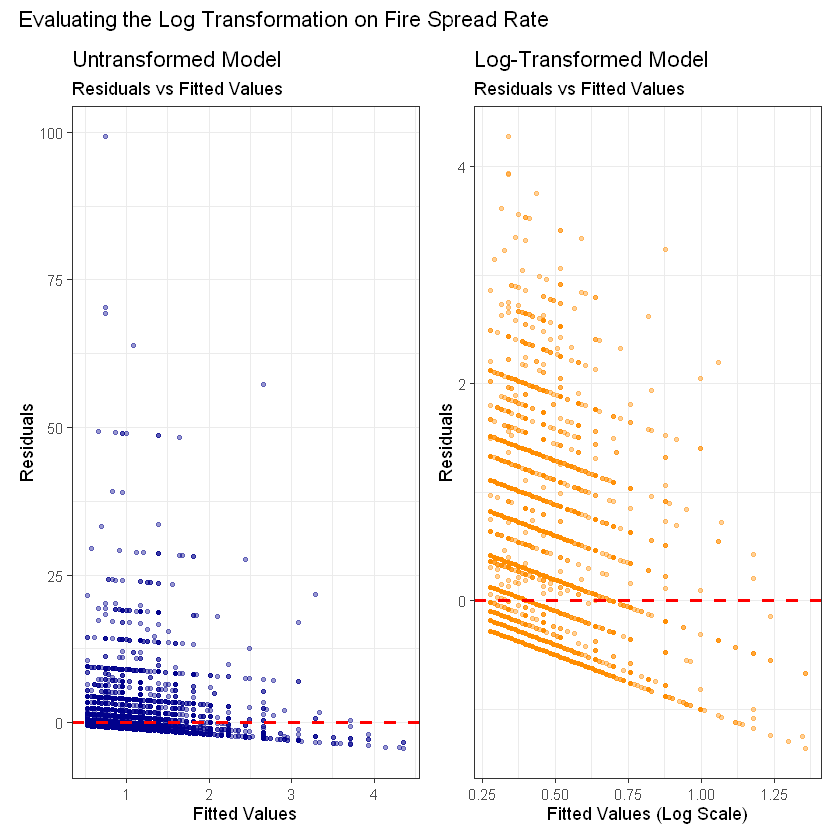

In [16]:

clean_wildfire_filtered <- clean_wildfire %>%
  filter(fire_spread_rate >= 0) %>%
  tidyr::drop_na(fire_spread_rate, wind_speed)


mod_untransformed <- lm(fire_spread_rate ~ wind_speed, data = clean_wildfire_filtered)
mod_log <- lm(log(fire_spread_rate + 1) ~ wind_speed, data = clean_wildfire_filtered)


df_untransformed <- augment(mod_untransformed)
df_log <- augment(mod_log)

# Plot Untransformed
plot_untransformed <- ggplot(df_untransformed, aes(x = .fitted, y = .resid)) +
  geom_point(alpha = 0.4, color = "darkblue", size = 1) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red", size = 1) +
  labs(
    title = "Untransformed Model",
    subtitle = "Residuals vs Fitted Values",
    x = "Fitted Values",
    y = "Residuals"
  ) +
  theme_bw()

# Plot Log-Transformed
plot_log <- ggplot(df_log, aes(x = .fitted, y = .resid)) +
  geom_point(alpha = 0.4, color = "darkorange", size = 1) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red", size = 1) +
  labs(
    title = "Log-Transformed Model",
    subtitle = "Residuals vs Fitted Values",
    x = "Fitted Values (Log Scale)",
    y = "Residuals"
  ) +
  theme_bw()

# Display side-by-side
plot_untransformed + plot_log + 
  plot_annotation(title = "Evaluating the Log Transformation on Fire Spread Rate")

**Figure 1: Evaluating the Log Transformation on Fire Spread Rate**
The residual plot for the untransformed simple linear model exhibited severe heteroscedasticity and extreme outliers. Applying a log(y+1) transformation successfully compressed these extreme values and stabilized the variance. However, the log-transformed residuals display distinct parallel diagonal bands rather than a random scatter. This structural pattern suggests that a simple linear model relying solely on wind speed is inadequate. It strongly reinforces the conclusion from our first visualization: we must build a multiple regression model that includes categorical control variables, such as fuel_type, to properly explain the variance in fire spread rates.

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 2891 rows containing non-finite outside the scale range
(`stat_smooth()`)."
Warning message:
"Removed 2880 rows containing missing values or values outside the scale range
(`geom_point()`)."


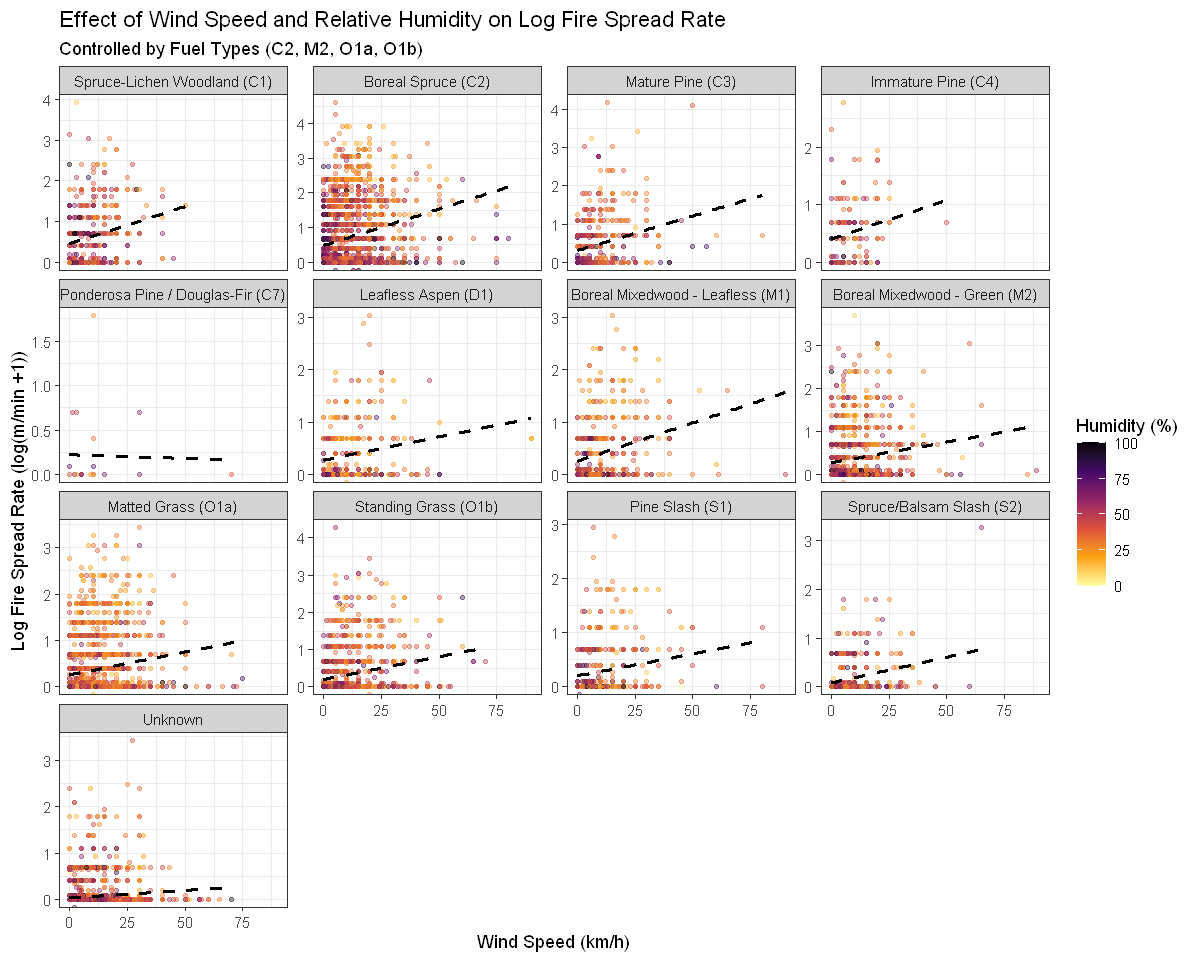

In [17]:
fuel_type_labels <- c(
  "C1"      = "Spruce-Lichen Woodland (C1)",
  "C2"      = "Boreal Spruce (C2)",
  "C3"      = "Mature Pine (C3)",
  "C4"      = "Immature Pine (C4)",
  "C6"      = "Conifer Plantation (C6)",
  "C7"      = "Ponderosa Pine / Douglas-Fir (C7)",
  "D1"      = "Leafless Aspen (D1)",
  "M1"      = "Boreal Mixedwood - Leafless (M1)",
  "M2"      = "Boreal Mixedwood - Green (M2)",
  "M3"      = "Dead Balsam Fir - Leafless (M3)",
  "M4"      = "Dead Balsam Fir - Green (M4)",
  "O1a"     = "Matted Grass (O1a)",
  "O1b"     = "Standing Grass (O1b)",
  "S1"      = "Pine Slash (S1)",
  "S2"      = "Spruce/Balsam Slash (S2)",
  "Unknown" = "Unknown"
)


options(repr.plot.width = 10, repr.plot.height = 8)


ggplot(clean_wildfire, aes(x = wind_speed, y = log(fire_spread_rate + 1))) +
  geom_point(aes(color = relative_humidity), alpha = 0.4, size = 1) +
  geom_smooth(method = "lm", color = "black", linetype = "dashed", se = FALSE) +
  facet_wrap(~ fuel_type, scales = "free_y", labeller = as_labeller(fuel_type_labels)) +
  scale_color_viridis_c(option = "inferno", direction = -1) +
  labs(
    title = "Effect of Wind Speed and Relative Humidity on Log Fire Spread Rate",
    subtitle = "Controlled by Fuel Types (C2, M2, O1a, O1b)",
    x = "Wind Speed (km/h)",
    y = "Log Fire Spread Rate (log(m/min +1))",
    color = "Humidity (%)"
  ) +
  theme_bw() +
  theme(strip.background = element_rect(fill = "lightgray"))


**Figure 2: Effect of Wind Speed and Relative Humidity on Log Fire Spread Rate**

This visualization explores how multiple meteorological predictors simultaneously influence fire behavior across different environments. The response variable, fire spread rate, was log-transformed (log(fire_spread_rate + 1)) to mitigate heavy right-skewness and compress extreme outliers, which will help satisfy the normality and constant variance assumptions required for our subsequent linear regression models.

By mapping wind speed to the x-axis and relative humidity to the color gradient, we can observe the combined effect of these weather conditions. Across the majority of fuel types, there is a clear, positive linear association (indicated by the black dashed lines) between wind speed and the log fire spread rate. Furthermore, the color gradient reveals that lower relative humidity (lighter yellow/orange points) frequently coincides with higher fire spread rates for a given wind speed, aligning with the physical expectation that drier conditions exacerbate fire spread.

Finally, faceting the plot by vegetation category (fuel_type) visually isolates the environment. We can observe that the baseline spread rate (the y-intercept) and the sensitivity to wind (the slope of the trend line) vary noticeably between distinct vegetation types—for instance, Standing Grass (O1b) shows a steeper response to wind compared to Spruce-Lichen Woodland (C1). This confirms that fuel type strongly dictates baseline fire behavior and serves as a crucial control variable; it must be held constant in a multiple regression model to accurately infer the independent, unbiased effects of the weather variables.

In [18]:
### Transform Variables


# clean_wildfire

transformed_clean_wildfire <- clean_wildfire |>
  # 1. REMOVE negative placeholders before logging
  filter(fire_spread_rate >= 0) |> 
  
  # 2. Now it is safe to log
  mutate(fire_spread_rate = log(fire_spread_rate + 1)) |>  
  mutate(wind_speed_sq = wind_speed^2) |>
    # 3. Double-check for any bizarre Inf values just to be bulletproof
  filter(!is.infinite(fire_spread_rate))
  cat("Table 3: Sample of Transformed Cleaned Wildfire Dataset and Selected Variables")
  head(transformed_clean_wildfire, 3)

Table 3: Sample of Transformed Cleaned Wildfire Dataset and Selected Variables

fire_spread_rate,temperature,relative_humidity,wind_speed,weather_conditions_over_fire,fuel_type,fire_position_on_slope,assessment_hectares,fire_type,wind_speed_sq
<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<dbl>,<fct>,<dbl>
0,18,10,2,Clear,O1a,Flat,0.01,Surface,4
0,12,22,10,Clear,O1a,Lower 1/3,0.20,Surface,100
0,12,22,10,Clear,O1a,Bottom,0.50,Surface,100


In [19]:
#percent NAs per variable
  cat("Table 4: Sample of Mising Data")
na_percentages <- colMeans(is.na(wildfire)) * 100
missing_data_table <- tibble(
  Variable = names(na_percentages),
  Percentage_NA = na_percentages
) |>
  arrange(desc(Percentage_NA)) |>
  head(5)

  # See how many rows you have before and after droping NA's
# nrow(wildfire)
# nrow(drop_na(wildfire))
# colSums(is.na(wildfire)) |> sort(decreasing = TRUE)
# nrow(clean_wildfire)
# nrow(drop_na(clean_wildfire))
# colSums(is.na(clean_wildfire)) |> sort(decreasing = TRUE)
# Creating the summary data frame
cleaning_summary <- tribble(
  ~Metric, ~wildfire, ~clean_wildfire,
  "Total Observations", "26,551", "23,549",
  "Rows lost to drop_na()", "10,600", "3,002",
  "Data Retention (%)", "60.1%", "88.7%",
  "Top Offender 1", "ia_arrival_at_fire_date (7,703)", "REMOVED",
  "Top Offender 2", "fire_fighting_start_date (7,572)", "REMOVED"
)

head(missing_data_table)
cat("Table 5: Summary of Data Cleaning and Row Retention")
# Outputting as a clean table
kable(cleaning_summary)
# percent of each category

cat("Table 6: Percentage of categories in fuel_type")
wildfire |>
  count(fuel_type) |>
  mutate(percentage = n / sum(n) * 100) |>
  arrange(desc(percentage))
  
cat("Table 7: Large Percentage 0s in fire_spread_rate")
wildfire |>
  summarize(
    total_fires = n(),
    zero_spread_count = sum(fire_spread_rate == 0.0),
    percentage_zero = (zero_spread_count / total_fires) * 100
  )

Table 4: Sample of Mising Data

Variable,Percentage_NA
<chr>,<dbl>
ia_arrival_at_fire_date,29.01209
fire_fighting_start_date,28.51870
wind_speed,10.84705
relative_humidity,10.83952
temperature,10.81692


Table 5: Summary of Data Cleaning and Row Retention



|Metric                 |wildfire                         |clean_wildfire |
|:----------------------|:--------------------------------|:--------------|
|Total Observations     |26,551                           |23,549         |
|Rows lost to drop_na() |10,600                           |3,002          |
|Data Retention (%)     |60.1%                            |88.7%          |
|Top Offender 1         |ia_arrival_at_fire_date (7,703)  |REMOVED        |
|Top Offender 2         |fire_fighting_start_date (7,572) |REMOVED        |

Table 6: Percentage of categories in fuel_type

fuel_type,n,percentage
<chr>,<int>,<dbl>
Unknown,7559,28.469737486
C2,6785,25.554593047
O1a,4191,15.784716207
M2,2367,8.914918459
O1b,2005,7.551504651
C3,715,2.692930586
M1,705,2.655267222
C1,586,2.207073180
S1,510,1.920831607


Table 7: Large Percentage 0s in fire_spread_rate

total_fires,zero_spread_count,percentage_zero
<int>,<int>,<dbl>
26551,12487,47.03024


The 2 variables that have the highest percentage of NAs at 29% are irrelevant because they do not affect the initial fire spread rate. The other variabales are <11% NAs. These 2 variables `ia_arrival_at_fire_date` `fire_fighting_start_date` were removed to preserve the rest of the dataset not only because of their high % of NAs but also because they are irrelevant to fire_spread_rate.  <br>

The "Unknown" and "C2" fuel types take up the majority of the observations. The "Unknown" could be any combination of the other fuel types.


Much of the fire_spread_rate is exactly 0.0 metres/minute at the time of assessment.

# (c) Methods: Plan

The objective of this analysis is twofold: to build a robust predictive model for wildfire spread rates and to conduct valid statistical inference to understand the conditional effects of meteorological and environmental factors. To achieve this without violating core statistical assumptions, we implemented a data-splitting strategy combined with penalized regression for variable selection.

Data Preparation and Splitting
Prior to modeling, the dataset was filtered to strictly remove missing observations using case-wise deletion, ensuring complete matrices for the regression algorithms. The clean data was then randomly partitioned into a training set (80%) and a testing set (20%). To preserve the distribution of our right-skewed, log-transformed response variable across both sets, this split was stratified by the fire_spread_rate.

Variable Selection Strategy (Training Data)
Given the complex nature of wildfire behavior, we hypothesized that the effect of weather variables depends heavily on the surrounding environment. To capture this, we generated a model matrix containing all original main effects alongside all possible two-way interactions (.)^2.

Because this extensive interaction matrix introduces high dimensionality and a severe risk of multicollinearity, manual selection is inappropriate. Instead, we employed a LASSO (Least Absolute Shrinkage and Selection Operator) regression on the training data. LASSO applies an L1 penalty to the regression coefficients, effectively shrinking the coefficients of less important variables exactly to zero. We utilized 10-fold cross-validation (cv.glmnet) to empirically determine the optimal penalty parameter (lambda.min) that minimizes the mean cross-validated error.

Prediction Model Assessment
For the primary prediction objective, the optimized LASSO model was used directly. Predictions were generated on the unseen testing data using the lambda.min penalty. To assess the model's predictive accuracy, we evaluated the Root Mean Square Error (RMSE) and the coefficient of determination (R-squared). Because the response variable was previously log-transformed (log(fire_spread_rate + 1)), these performance metrics reflect the model's accuracy on the log scale, evaluating its ability to predict the order of magnitude of fire spread rather than raw metric distance.

Post-Selection Inference (Testing Data)
To address the inferential objective—quantifying the specific impact of the variables—we required unpenalized coefficients and valid p-values. Extracting p-values directly from a LASSO model is statistically invalid, and fitting a standard Multiple Linear Regression (MLR) on the same training data used for selection results in "double-dipping," leading to overly optimistic, biased p-values.

To overcome this, we used the training data strictly for structural learning: extracting the non-zero active coefficients from the optimal LASSO model to dictate our final formula (comprising a specific mix of main effects like fuel_type and interactions like temperature:fuel_type). We then fitted a standard, unpenalized MLR model using this derived formula strictly on the held-out testing data. By splitting the variable selection (training set) from the inferential estimation (testing set), we ensured that the resulting standard errors, confidence intervals, and p-values in the final MLR summary remain statistically valid and unbiased for interpretation.

In [20]:
# 1. Final Safety Check (Ensure X and Y dimensions will match) - model.matrix automatically ommits NAs
clean_wildfire_model_data <- transformed_clean_wildfire |> drop_na()

# 2. Train / Test Split
set.seed(123)
initial_split_obj <- initial_split(clean_wildfire_model_data, prop = 0.80, strata = fire_spread_rate)
training_data <- training(initial_split_obj)
testing_data <- testing(initial_split_obj)

# 3. Build the Training Matrix
x_train <- model.matrix(
  fire_spread_rate ~ (.)^2,
  data = training_data
)[, -1]

y_train <- training_data$fire_spread_rate

# 4. Train the LASSO Model
cv_lasso <- cv.glmnet(x_train, y_train, alpha = 1)

# 5. Build the Testing Matrix & Predict
x_test <- model.matrix(
  fire_spread_rate ~ (.)^2,
  data = testing_data
)[, -1]

lasso_predictions <- predict(cv_lasso, newx = x_test, s = "lambda.min")

# 6. Evaluate Performance (Log-Scale)
testing_data_with_preds <- testing_data |>
  mutate(predicted_rate = as.numeric(lasso_predictions))



In [21]:
# Calculate metrics on the log-scale
metrics <- metric_set(rmse, rsq)


# Calculate metrics, drop .estimator column, and rename for the report
metrics_table <- testing_data_with_preds |>
  metrics(truth = fire_spread_rate, estimate = predicted_rate) |>
  select(Metric = .metric, Value = .estimate) |>
  mutate(Value = round(Value, 4))

# Print the title 
cat("Table 8: LASSO Model Performance Metrics on Unseen Test Data")

# Generate the table 
kable(metrics_table, format = "markdown")

# Extract coefficients at the optimal lambda
lasso_coefs <- coef(cv_lasso, s = "lambda.min")

# Convert the sparse matrix to a data frame
coef_df <- as.data.frame(as.matrix(lasso_coefs))

# Force the column name to "Coefficient" to avoid the 's1' error
colnames(coef_df) <- c("Coefficient")

# Clean it up into a tidy format
active_coefs_table <- coef_df |>
  rownames_to_column(var = "Predictor") |>
  filter(Coefficient != 0) |>           # Remove the variables LASSO shrunk to exactly 0
  arrange(desc(abs(Coefficient))) |>    # Sort by strongest effect, but keep the +/- sign!
  mutate(Coefficient = round(Coefficient, 4))

# Print the title y
cat("Table 9: Non-Zero LASSO Coefficients Ranked by Magnitude")

# Generate the table (NO caption argument here)
kable(active_coefs_table, format = "markdown")



Table 8: LASSO Model Performance Metrics on Unseen Test Data



|Metric |  Value|
|:------|------:|
|rmse   | 0.5099|
|rsq    | 0.2734|

Table 9: Non-Zero LASSO Coefficients Ranked by Magnitude



|Predictor                                      | Coefficient|
|:----------------------------------------------|-----------:|
|(Intercept)                                    |      0.4882|
|fire_typeGround                                |     -0.2506|
|fuel_typeUnknown                               |     -0.1385|
|fire_typeSurface                               |     -0.1219|
|fuel_typeUnknown:fire_typeSurface              |     -0.0103|
|temperature:fuel_typeC2                        |      0.0086|
|wind_speed:fuel_typeC2                         |      0.0045|
|temperature:fuel_typeUnknown                   |     -0.0034|
|relative_humidity:fire_typeSurface             |     -0.0024|
|temperature                                    |      0.0024|
|relative_humidity:fire_typeGround              |     -0.0013|
|temperature:fire_position_on_slopeFlat         |      0.0006|
|temperature:wind_speed                         |      0.0004|
|fire_position_on_slopeFlat:assessment_hectares |    

In [ ]:
selected_formula <- fire_spread_rate ~ fire_type +
fuel_type +
temperature:fuel_type +
temperature +
wind_speed:fuel_type +
wind_speed +
relative_humidity:fire_type +
relative_humidity +
fuel_type:fire_position_on_slope +
fire_position_on_slope +
temperature:fire_position_on_slope +
temperature:wind_speed +
assessment_hectares  +
temperature:assessment_hectares +
wind_speed:assessment_hectares 



# ---------------------------------------------------------
# Post-selection. Fitting the linear model to testing_data for inference
# ---------------------------------------------------------

inference_model <- lm(selected_formula, data = testing_data)


#summary(inference_model)

# 4. Print the clean Table Title
cat("Table 10: Significant Coefficients from Inference Model (p < 0.05)")


inference_model_results <- tidy(inference_model, conf.int = TRUE) |>
    # 1. Filter for significance first (keep only p < 0.05)
    filter(p.value < 0.05) |>
    # 2. Round the numeric values for the report
    mutate(across(where(is.numeric), ~ round(., 4))) |>
    # 3. Optional: Rename for a cleaner table
    rename(
      Predictor = term,
      Estimate = estimate,
      `P-Value` = p.value,
      `Conf Low` = conf.low,
      `Conf High` = conf.high
    )
inference_model_results
# 1. Create a tidy dataframe for the overall stats
overall_stats_table <- tibble(
  Statistic = c(
    "Residual Standard Error", 
    "Degrees of Freedom", 
    "Multiple R-squared", 
    "Adjusted R-squared"
  ),
  Value = c(
    "0.4811",
    "4626", 
    "0.3519", 
    "0.3374"
  )
)

# 2. Print the title manually to avoid the "Table: Table" glitch
cat("Table 11: Inference Model Goodness-of-Fit Statistics")

# 3. Generate the clean Markdown table
kable(overall_stats_table, format = "markdown")

Table 10: Significant Coefficients from Inference Model (p < 0.05)

Predictor,Estimate,std.error,statistic,P-Value,Conf Low,Conf High
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.9057,0.3168,2.8592,0.0043,0.2847,1.5267
fire_typeGround,-1.3088,0.0971,-13.4763,0.0000,-1.4991,-1.1184
fire_typeSurface,-1.1118,0.0918,-12.1129,0.0000,-1.2917,-0.9319
fuel_typeO1a,0.6039,0.3021,1.9990,0.0457,0.0116,1.1961
fuel_typeO1b,0.6402,0.3125,2.0485,0.0406,0.0275,1.2529
wind_speed,0.0217,0.0061,3.5816,0.0003,0.0098,0.0337
relative_humidity,-0.0113,0.0019,-5.9227,0.0000,-0.0151,-0.0076
fire_position_on_slopeFlat,0.5398,0.2586,2.0872,0.0369,0.0328,1.0467
assessment_hectares,-0.0015,0.0004,-3.7203,0.0002,-0.0024,-0.0007


Table 11: Inference Model Goodness-of-Fit Statistics



|Statistic               |Value  |
|:-----------------------|:------|
|Residual Standard Error |0.4811 |
|Degrees of Freedom      |4626   |
|Multiple R-squared      |0.3519 |
|Adjusted R-squared      |0.3374 |

`geom_smooth()` using formula = 'y ~ x'


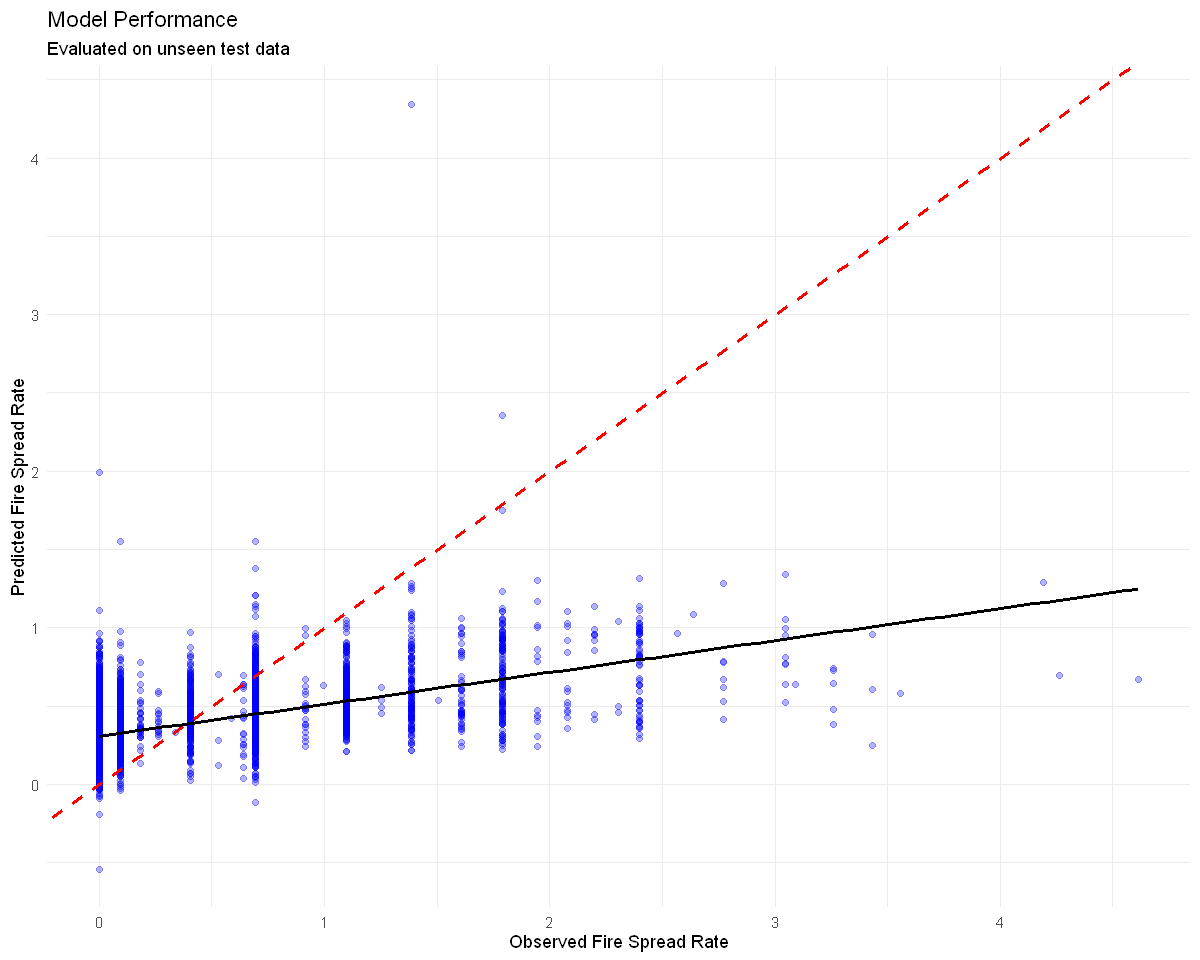

In [23]:
ggplot(testing_data_with_preds, aes(x = fire_spread_rate, y = predicted_rate)) +
  geom_point(alpha = 0.3, color = "blue") +
  geom_abline(intercept = 0, slope = 1,          # Adds the "Perfect Prediction" reference line
              color = "red", linetype = "dashed", size = 1) +
  geom_smooth(method = "lm", color = "black", se = FALSE) + # Adds the actual trend of predictions
  labs(
    title = "Model Performance",
    subtitle = "Evaluated on unseen test data",
    x = "Observed Fire Spread Rate",
    y = "Predicted Fire Spread Rate"
  ) +
  theme_minimal()

**Figure 3: Predicted vs. Observed Log-Transformed Fire Spread Rates**

**Figure 3.** Comparison of observed and predicted values for the log-transformed fire spread rate ($\log(x+1)$) using the unseen testing dataset. The red dashed line represents the identity line ($y = x$) for a theoretically perfect model, while the black solid line indicates the actual linear regression trend of the model's predictions. The divergence between the black and red lines at higher observed values highlights a systematic under-prediction bias for high-intensity fire spread events.

In [24]:
# Define a null model and a full model
wildfire_null <- lm(fire_spread_rate ~ 1, data = training_data)
wildfire_all <- lm(fire_spread_rate ~., data = training_data)

In [ ]:
# Add a column with predictions to the validation set (fit_data)
test_predictions <- training_data %>%
    add_predictions(inference_model, var = "pred_LASSO") %>%
    add_predictions(wildfire_null, var = "pred_null") %>%
    add_predictions(wildfire_all, var = "pred_all")

# Calculate RMSE and R-squared to assess accur acy
metrics <- metric_set(rmse, rsq, mae)

# Add GOF metrics for null and interaction model
metrics_summary <- cbind(
    metrics(test_predictions, truth = fire_spread_rate, estimate = pred_LASSO),
    all = metrics(test_predictions, truth = fire_spread_rate, estimate = pred_all)$.estimate,
    null = metrics(test_predictions, truth = fire_spread_rate, estimate = pred_null)$.estimate
)

metrics_summary <- rename(metrics_summary, lasso = .estimate)
cat("Table 12: Comparison of Inference Model to null and full model")
metrics_summary

Warning message in predict.lm(model, data):
"prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases"
Warning message:
"A correlation computation is required, but `estimate` is constant and has 0
standard deviation, resulting in a divide by 0 error. `NA` will be returned."


Table 11: Comparison of Inference Model to null and full model

.metric,.estimator,lasso,all,null
<chr>,<chr>,<dbl>,<dbl>,<dbl>
rmse,standard,0.5211016,0.4867723,0.5854620
rsq,standard,0.2441713,0.3087195,NA
mae,standard,0.3551704,0.3574004,0.4555807


The Table 12 contains goodness-of-fit metrics for the MLR model fitted through LASSO variable selection, the null model (intercept only) and the full model with all predictors. The LASSO model is outperformed by the full model with all the predictors as it as a higher $R^2$ value (0.31 vs. 0.24) and a lower RMSE (0.49 vs. 0.52). This is expected as $R^2$ will not decrease and RMSE will not increase when adding more predictors to a model (https://statisticsbyjim.com/regression/root-mean-square-error-rmse/). The MAE values between the LASSO and full model are nearly identical (0.355 vs. 0.357), indicating that the predictions made by both models have similar average errors, despite the difference in number of predictors.

# (4) Discussion

#### Summary of Findings

The primary goal of this investigation was to evaluate the predictive power of weather-related variables on wildfire spread in Alberta and to infer which environmental factors share the strongest association with that spread. Using a LASSO-regularized linear model with two-way interactions, we achieved an $R^2$ of 0.273 on the unseen test set. This indicates that while our model is statistically significant, it only explains approximately 27.3% of the variability in the log-transformed fire spread rate.

#### Predictive Model Findings
As illustrated in Figure 3, the model demonstrates a persistent under-prediction bias. While it tracks relatively well for low-spread fires, the predictions "plateau" as the actual spread rate increases. The black regression line is significantly flatter than the $y = x$ identity line, suggesting that a linear combination of predictors—even with interaction terms like temperature:wind_speed—cannot fully capture the explosive, non-linear growth typical of high-intensity fires. Given that the RMSE (0.510) and MAE values are only marginally better than a null model, we conclude that the model has low predictive power for high-impact events, though it successfully identifies key associative trends for general fire behavior. Table 8 also shows the $R^2$ of .273 which indicates that only 27.3% of the variability is explained.


#### Inference Model Findings
The inference model fit through LASSO variable selection is performing slightly better than the full model and the null model, but still has low $R^2$ (0.244 on the test set). This indicates that only about 24.4% of the variability is explained, which is relatively low for predictive purposes, though not unexpected given the complex interactions between environmental variables. The RMSE and MAE values are not much lower than the null model, indicating that the LASSO model has low predictive power. LASSO selects variables by penalizing and removing the least important ones, so the low predictive power of this model suggests that even the best subset of predictors may not be strongly associated with the response variable. The analysis may be missing more powerful predictors such as the weather conditions over the fire (rainy vs. clear day) or the firefighting techniques used on it.


Our inference model (Adjusted $R^2 = 0.337$) provided deeper insight into the specific drivers of spread. Most notably, wind speed ($p < 0.001$) and relative humidity ($p < 0.001$) exhibited highly significant associations with the spread rate. As expected, higher wind speeds were associated with faster spread, while higher humidity was associated with a decrease.Interestingly, temperature was not a significant predictor in isolation ($p = 0.223$). However, its interactions, specifically temperature:wind_speed and temperature:assessment_hectares—were highly significant ($p < 0.01$). This suggests that in the Alberta dataset, temperature acts as a "force multiplier" rather than a direct driver; it significantly accelerates spread only when high winds are present or when the fire has already reached a substantial size. Furthermore, fire type (Ground and Surface fires) showed a massive negative association with spread rate compared to Crown fires ($p < 0.001$), confirming that the vertical structure of the forest fuel is a primary determinant of horizontal spread.

#### Reflections on Expectations
These results were partially consistent with our expectations. Based on the "Fire Behavior Triangle," (heat, fuel and oxygen) we anticipated that wind speed and temperature would be the dominant predictors; the LASSO model confirmed this by retaining these variables and their interactions. However, the $R^2$ was lower than expected. We hypothesized that weather would account for a larger share of the variance, but the results suggest that in Alberta’s complex boreal landscape, fuel moisture and topography likely carry more weight than ambient atmospheric conditions alone.

#### Model Improvement
While LASSO regression performs variable selection, it does not guarantee that all the multicollinearity is removed. Therefore, theoretically, performing a Variance Inflation Factor (VIF) test as a post-selection helps ensure that the final model with stable coefficients and minimized standard errors. Variables that have a VIF higher than 5 or 10 suggest that LASSO may have retained problematic multicollinearity.

#### Improvements and Future Research
To improve the model’s predictive power, future iterations should move beyond linear models. Implementing machine learning techniques like Random Forests or Gradient Boosting would likely better capture the non-linear thresholds where fire behavior shifts from "surface" to "crown" fires.

Future research should also integrate spatial-temporal data, such as the "Drought Code" (long-term moisture deficits) and digital elevation models to account for slope. A key question for future study is how the interaction between fuel type and slope affects spread, as fire moves significantly faster uphill—a variable currently missing from our analysis.

#### Future questions and research
This study could lead to several future research questions related to wildfire size. For example, after examining how environmental conditions affect fire spread rate, we could test whether the same variables also influence a wildfire's size. Furthermore, our future research could examine whether temperature, wind speed, and relative humidity not only affect how a fire spreads, but also how large it eventually becomes. We could add more variables in the future to make the study more precise and clear, such as fuel type, weather, fire type, and fire cause, thereby improving our understanding of wildfire. Our current study can serve as a starting point for broader research on how environmental and landscape conditions will affect wildfire behaviour.

### Assumptions and Limitations

The validity of our findings is constrained by several statistical, environmental, and dataset-specific limitations:

* **Linearity, Normality, and Homoscedasticity:** A core assumption of Multiple Linear Regression (MLR) is a linear relationship, alongside normally distributed errors and constant variance. However, wildfire behavior is notoriously non-linear, and the variance of spread rates likely increases as fires grow larger, violating the equal variance assumption. While we utilized a $\log(x+1)$ transformation to stabilize variance and handle the right-skewed data, this mathematical adjustment cannot fully account for the exponential "blow-up" phases of wildfires where spread rates accelerate rapidly. 

* **Independence of Observations:** We assume each entry in the Alberta Wildfire Service database represents an independent event. In reality, large fire complexes or fires occurring in close spatial and temporal proximity may be correlated, potentially affecting the independence of our residuals.

* **Multicollinearity:** Meteorological factors like temperature and relative humidity are naturally inversely correlated. While we utilized LASSO to mitigate this by shrinking redundant coefficients to zero, the inherent relationship between these variables makes isolating the unique "individual" association of one factor challenging.

* **Confounding Variables:** Our model lacks data on localized topography (slope and aspect), brush density, and antecedent weather conditions (how dry the fuel was in the weeks preceding the fire). Furthermore, the dataset does not account for human intervention, such as firefighting techniques or suppression efforts, which significantly alter the "natural" spread rate of a fire.

* **Data Quality and Zero-Inflation:** A significant limitation of the dataset is that approximately 47% of the `fire_spread_rate` values are recorded as 0 m/min. This high proportion of zero values creates a "zero-inflated" distribution that standard linear regression struggles to model accurately. Additionally, a large proportion of categorical data (such as fire position on slope or fuel type) is labeled as 'Unknown,' which dilutes the predictive power of those specific features.

# (5) References


1. Jain, P., Wang, X., & Flannigan, M. D. (2023). <br>
    Critical fire weather conditions during active fire spread days in Canada. Science of The Total Environment, 869, 161831. <br>
    https://doi.org/10.1016/j.scitotenv.2023.161831

2. Burak K, Khoda E, Piran A, Ramirez F, Subrahmanian S (2026). <br>
    _diversedata: A Curated Collection of Datasets on Diverse Topics_. R<br>
     package version 1.0.1, commit
    4d9ebacf2d2afa0a3aa3ab894492f3482117f1f3,<br>
     <https://github.com/diverse-data-hub/diversedata>.<br>